In [313]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [314]:
data = pd.read_csv("mnist_train.csv")

In [316]:
data.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [317]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [318]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

In [319]:
print(m,n)

60000 785


In [320]:
train_data = data[0:int(0.8*m), :]
val_data = data[int(0.8*m):m, :]

X_train = train_data[:, 1:].T
X_train = X_train/255.0
Y_train = train_data[:, 0]

X_val = val_data[:, 1:].T
X_val = X_val/255.0
Y_val = val_data[:, 0]

In [321]:
Y_train

array([8, 9, 9, ..., 6, 5, 6], dtype=int64)

In [322]:
print(X_train.shape)
print(Y_train.shape)
print(X_val.shape)
print(Y_val.shape)

(784, 48000)
(48000,)
(784, 12000)
(12000,)


In [365]:
def initialize_para():
    
    W1 = np.random.rand(128,784) - 0.5
    b1 = np.random.rand(128,1) - 0.5
    W2 = np.random.rand(10,128) - 0.5
    b2 = np.random.rand(10,1) - 0.5
    
    
    return W1, b1, W2, b2

In [366]:
def ReLu(x):
    return np.maximum(x,0)

In [367]:
def softmax(Z):
    return np.exp(Z) / sum(np.exp(Z))

In [368]:
def forward_propagation(X,W1,W2,b1,b2):

    Z1 = np.dot(W1,X) + b1
    A1 = ReLu(Z1)
    Z2 = np.dot(W2,A1) + b2
    A2 = softmax(Z2)
   

    return Z1, A1, Z2, A2

In [369]:
def ReLu_derivative(x):
    return (x > 0).astype(float)

In [370]:
def one_hot_converter(y):
    
    one_hot_y = np.zeros((y.size , y.max() + 1))
    one_hot_y[np.arange(y.size) , y] = 1

    return one_hot_y.T

In [371]:
def backward_propagation(W1, b1, W2, b2, Z1, A1, Z2, A2, X, Y):

    
    one_hot_y = one_hot_converter(Y)
    
    dZ2 = A2 - one_hot_y
    dW2 = 1/m * dZ2.dot(A1.T)
    db2 = 1/m * np.sum(dZ2)
    
    dZ1 = W2.T.dot(dZ2) * ReLu_derivative(Z1)
    dW1 = 1/m * dZ1.dot(X.T)
    db1 = 1/m * np.sum(dZ1)
    
    
    return dW1, db1, dW2, db2
    

In [372]:
def update_param(W1, W2, b1, b2, dW1, dW2, db1, db2, learning_rate):

        W1 = W1 - learning_rate * dW1
        b1 = b1 - learning_rate * db1
        W2 = W2 - learning_rate * dW2
        b2 = b2 - learning_rate * db2
        
    
    
        return W1, W2, b1, b2

In [373]:
def cost_function(y, y_pred):
    return (-1/m) * np.sum(y * np.log(y_pred))

In [374]:
def accuracy(predictions, y):
    return np.sum(y == predictions) / y.size

In [375]:
def get_predictions(x):
    return np.argmax(x, 0)

In [376]:
def gradient_descent(X, y, learning_rate, iteration):

    W1, b1, W2, b2 = initialize_para()
    cost_list = []
    iteration_list = []
    for i in range(iteration):
        
        Z1, A1, Z2, A2 = forward_propagation(X,W1,W2,b1,b2)
        dW1, db1, dW2, db2 = backward_propagation(W1, b1, W2, b2, Z1, A1, Z2, A2, X, y)
        W1, W2, b1, b2= update_param(W1, W2, b1, b2, dW1, dW2, db1, db2, learning_rate)

        if i%20 == 0:
            one_hot_y = one_hot_converter(y)
            current_cost = cost_function(one_hot_y, A2) 
            cost_list.append(current_cost)
            iteration_list.append(i)
            print("iteration number: ", i)
            print("cost: ", cost_function(one_hot_y, A2))
            print("accuracy: ", accuracy( get_predictions(A2),y))
            
    plt.title("Cost function evolution (training)")
    plt.xlabel("Iteration number")
    plt.ylabel("Loss")
    plt.plot(iteration_list, cost_list)
    plt.show()
        
    return W1, W2, b1, b2
    

iteration number:  0
cost:  5.979990021117689
accuracy:  0.09297916666666667
iteration number:  20
cost:  1.2121637647817531
accuracy:  0.56125
iteration number:  40
cost:  0.8554235840374939
accuracy:  0.6761875
iteration number:  60
cost:  0.7078875246307764
accuracy:  0.7299791666666666
iteration number:  80
cost:  0.6213766022766736
accuracy:  0.7623125
iteration number:  100
cost:  0.5625650947034145
accuracy:  0.7859375
iteration number:  120
cost:  0.5191626755068683
accuracy:  0.8031458333333333
iteration number:  140
cost:  0.4854285248444583
accuracy:  0.8163958333333333
iteration number:  160
cost:  0.45828178214527243
accuracy:  0.82775
iteration number:  180
cost:  0.4357756135377477
accuracy:  0.8370416666666667
iteration number:  200
cost:  0.416732666158054
accuracy:  0.8445208333333334
iteration number:  220
cost:  0.40034961395659147
accuracy:  0.85025
iteration number:  240
cost:  0.38608275366317624
accuracy:  0.8556666666666667
iteration number:  260
cost:  0.37349

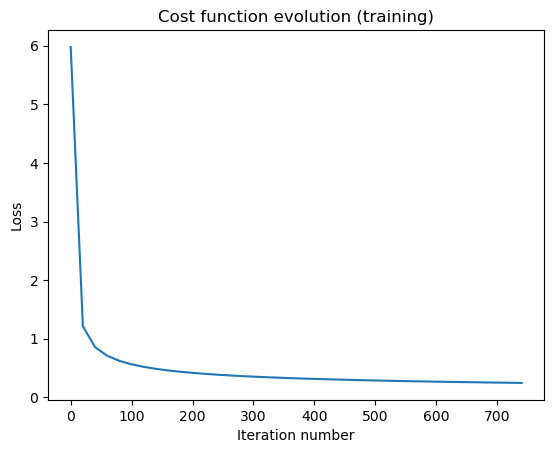

In [377]:
W1, W2, b1, b2 =  gradient_descent(X_train, Y_train, 0.1, 750)

prediction:  [9]
actual label:  9


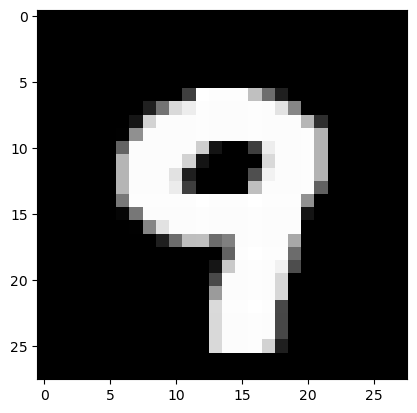

In [394]:
image_num = 98
Z1_val, A1_val, Z2_val, A2_val = forward_propagation(X_val[:,image_num,None],W1,W2,b1,b2)
y_pred = get_predictions(A2_val)
print("prediction: ", y_pred)
print("actual label: ", Y_val[image_num])

plt.imshow(X_val[:,image_num].reshape(28,28), cmap = 'grey')
plt.show()

In [427]:
Z1_val, A1_val, Z2_val, A2_val, Z3_val,A3_val = forward_propagation(X_val,W1,W2,W3,b1,b2,b3)
final_accuracy = accuracy(get_predictions(A3_val), Y_val)
print("Final accuray = ", final_accuracy)

Final accuray =  0.8695
